<a href="https://colab.research.google.com/github/NazHub1993/Deep-Learning/blob/main/Customer_Churn_Prediction(ANN)%5BArtificial_Neural_Network%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [74]:
df=pd.read_csv('customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [75]:
df.drop('customerID',axis='columns',inplace=True)

In [76]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [77]:
df.TotalCharges.values

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [78]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [79]:
df['TotalCharges'].dtype

dtype('float64')

In [80]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [81]:
df.shape

(7043, 20)

In [82]:
df.dropna(subset=['TotalCharges'],inplace=True)

In [83]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [84]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


#Time to visualize the tenure

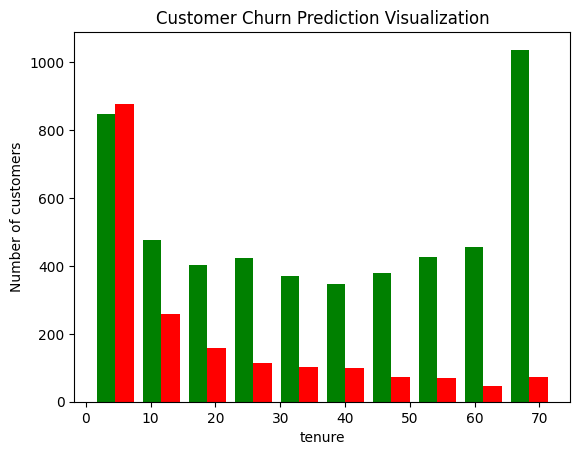

In [85]:
tenure_churn_no=df[df.Churn=="No"].tenure
tenure_churn_yes=df[df.Churn=="Yes"].tenure

plt.xlabel("tenure")
plt.ylabel("Number of customers")
plt.title("Customer Churn Prediction Visualization")

plt.hist([tenure_churn_no,tenure_churn_yes],color=['green','red'],label=['churn==no','churn==yes'])
plt.show()

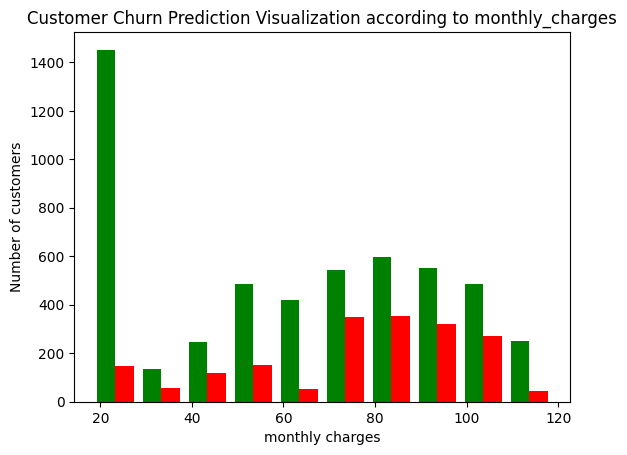

In [86]:
mc_churn_no=df[df.Churn=="No"].MonthlyCharges
mc_churn_yes=df[df.Churn=="Yes"].MonthlyCharges

plt.xlabel("monthly charges")
plt.ylabel("Number of customers")
plt.title("Customer Churn Prediction Visualization according to monthly_charges")

plt.hist([mc_churn_no,mc_churn_yes],color=['green','red'],label=['churn_no','churn_yes'])
plt.show()


#How to know which columns are of object type?

In [87]:
def print_unique_vals(df):
  for column in df:
    if df[column].dtype=='object':
      print(f'{column}: unique_values: {df[column].unique()}')

In [88]:
print_unique_vals(df)


gender: unique_values: ['Female' 'Male']
Partner: unique_values: ['Yes' 'No']
Dependents: unique_values: ['No' 'Yes']
PhoneService: unique_values: ['No' 'Yes']
MultipleLines: unique_values: ['No phone service' 'No' 'Yes']
InternetService: unique_values: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: unique_values: ['No' 'Yes' 'No internet service']
OnlineBackup: unique_values: ['Yes' 'No' 'No internet service']
DeviceProtection: unique_values: ['No' 'Yes' 'No internet service']
TechSupport: unique_values: ['No' 'Yes' 'No internet service']
StreamingTV: unique_values: ['No' 'Yes' 'No internet service']
StreamingMovies: unique_values: ['No' 'Yes' 'No internet service']
Contract: unique_values: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: unique_values: ['Yes' 'No']
PaymentMethod: unique_values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: unique_values: ['No' 'Yes']


In [89]:
df.replace('No internet service','No',inplace=True)
df.replace('No phone service','No',inplace=True)

In [90]:
print_unique_vals(df)

gender: unique_values: ['Female' 'Male']
Partner: unique_values: ['Yes' 'No']
Dependents: unique_values: ['No' 'Yes']
PhoneService: unique_values: ['No' 'Yes']
MultipleLines: unique_values: ['No' 'Yes']
InternetService: unique_values: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: unique_values: ['No' 'Yes']
OnlineBackup: unique_values: ['Yes' 'No']
DeviceProtection: unique_values: ['No' 'Yes']
TechSupport: unique_values: ['No' 'Yes']
StreamingTV: unique_values: ['No' 'Yes']
StreamingMovies: unique_values: ['No' 'Yes']
Contract: unique_values: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: unique_values: ['Yes' 'No']
PaymentMethod: unique_values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: unique_values: ['No' 'Yes']


#Turning the YES NO columns in 1 or 0

In [91]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
  df[col].replace({'Yes':1,'No':0},inplace=True)


/tmp/ipykernel_5964/414633514.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace({'Yes':1,'No':0},inplace=True)
/tmp/ipykernel_5964/414633514.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].replace({'Yes':1,'No':0},inplace=True)


In [92]:
print_unique_vals(df)


gender: unique_values: ['Female' 'Male']
InternetService: unique_values: ['DSL' 'Fiber optic' 'No']
Contract: unique_values: ['Month-to-month' 'One year' 'Two year']
PaymentMethod: unique_values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [93]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,object
OnlineSecurity,int64
OnlineBackup,int64


In [94]:
df['gender'].replace({'Male':0,'Female':1},inplace=True)

/tmp/ipykernel_5964/1735084570.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].replace({'Male':0,'Female':1},inplace=True)
/tmp/ipykernel_5964/1735084570.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'].replace({'Male':0,'Female':1},inplace=True)


#Now One Hot Encoding for the object type columns

In [95]:
df=pd.get_dummies(data=df,columns=['InternetService','Contract','PaymentMethod'])

In [96]:
for column in df:
  print(f"{column}:: {df[column].unique()}")

gender:: [1 0]
SeniorCitizen:: [0 1]
Partner:: [1 0]
Dependents:: [0 1]
tenure:: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService:: [0 1]
MultipleLines:: [0 1]
OnlineSecurity:: [0 1]
OnlineBackup:: [1 0]
DeviceProtection:: [0 1]
TechSupport:: [0 1]
StreamingTV:: [0 1]
StreamingMovies:: [0 1]
PaperlessBilling:: [1 0]
MonthlyCharges:: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges:: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn:: [0 1]
InternetService_DSL:: [ True False]
InternetService_Fiber optic:: [False  True]
InternetService_No:: [False  True]
Contract_Month-to-month:: [ True False]
Contract_One year:: [False  True]
Contract_Two year:: [False  True]
PaymentMethod_Bank transfer (automatic):: [False  True]
PaymentMethod_Credit card (automatic):: [False  True]
PaymentMethod_Electroni

#Scale the numeric cols

In [97]:
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

#Now my data frame is ready.

In [98]:
X=df.drop('Churn',axis='columns')
Y=df['Churn']

In [99]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [100]:
x_train.shape

(5625, 26)

#Build ANN in tensorflow

In [101]:
model=keras.Sequential(
    [
        keras.layers.Dense(20,input_shape=(26,),activation='relu'),
        keras.layers.Dense(15,activation='relu'),
        keras.layers.Dense(1,activation='sigmoid')
    ]
)

model.compile(
    optimizer='SGD',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train,y_train,epochs=50)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6852 - loss: 0.6077
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7342 - loss: 0.5405
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7353 - loss: 0.5088
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7490 - loss: 0.4785
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7765 - loss: 0.4568
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7899 - loss: 0.4439
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7924 - loss: 0.4366
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7950 - loss: 0.4321
Epoch 9/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7941 - loss: 0.4289
Epoch 10/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7989 - loss: 0.4262
Epoch 11/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7991 - loss: 0.4246
Epoch 12/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [102]:
model.evaluate(x_test,y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7889 - loss: 0.4367


[0.4367067515850067, 0.7889125943183899]

In [104]:
yp = model.predict(x_test)
y_pred = []
for element in yp:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [105]:
y_test[:5]

,Churn
2481,0
6784,0
6125,1
3052,0
4099,0


In [108]:
y_pred[:5]

[0, 0, 1, 0, 0]

In [107]:
from sklearn.metrics import confusion_matrix,classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Text(95.72222222222221, 0.5, 'Truth')

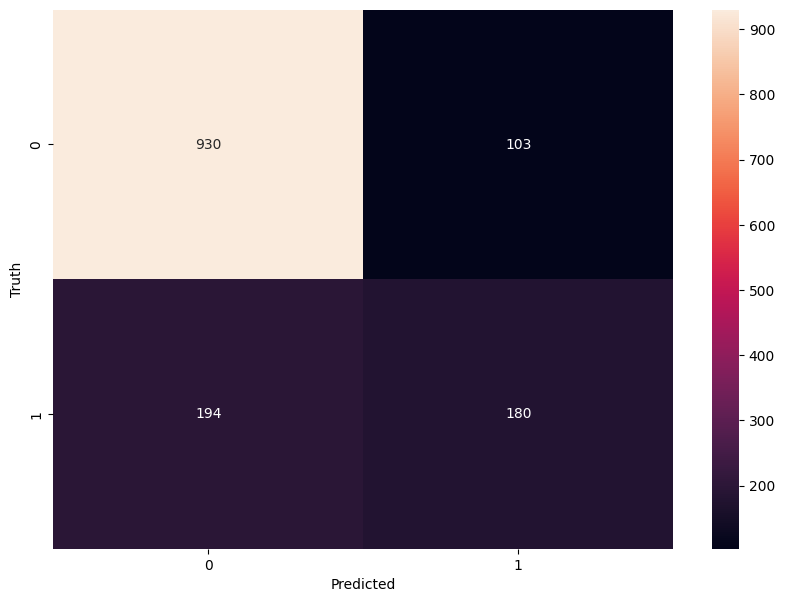

In [106]:
import seaborn as sn
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

#How to do undersampling

In [109]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.495307,0.162400,0.482509,0.298493,0.442560,0.903299,0.421928,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,0.463166,0.261309,0.265785
std,0.500014,0.368844,0.499729,0.457629,0.345708,0.295571,0.493902,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,0.299363,0.261571,0.441782
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.112676,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.172512,0.044155,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.394366,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.518408,0.159090,0.000000
75%,1.000000,0.000000,1.000000,1.000000,0.760563,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.712562,0.435719,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7032 non-null   int64  
 1   SeniorCitizen                            7032 non-null   int64  
 2   Partner                                  7032 non-null   int64  
 3   Dependents                               7032 non-null   int64  
 4   tenure                                   7032 non-null   float64
 5   PhoneService                             7032 non-null   int64  
 6   MultipleLines                            7032 non-null   int64  
 7   OnlineSecurity                           7032 non-null   int64  
 8   OnlineBackup                             7032 non-null   int64  
 9   DeviceProtection                         7032 non-null   int64  
 10  TechSupport                              7032 non-nul

In [111]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [112]:
from sklearn.utils import resample

majority_class=df[df['Churn']==0]
minority_class=df[df['Churn']==1]

majority_downsampled=resample(
    majority_class,
    n_samples=len(minority_class),
    random_state=42
)

balanced_df=pd.concat([majority_downsampled,minority_class])

In [113]:
balanced_df['Churn'].value_counts()

,count
Churn,
0,1869
1,1869


In [114]:
balanced_df.shape

(3738, 27)

In [115]:
X_u=balanced_df.drop('Churn',axis='columns')
Y_u=balanced_df['Churn']

x_train_u, x_test_u, y_train_u, y_test_u = train_test_split(X_u,Y_u,test_size=0.2,random_state=42)

In [116]:
x_train_u.shape

(2990, 26)

In [117]:
y_train_u.shape

(2990,)

In [130]:
model=keras.Sequential(
    [
        keras.layers.Dense(20,input_shape=(x_train_u.shape[1],),activation='relu'),
        keras.layers.Dense(15,activation='relu'),
        keras.layers.Dense(1,activation='sigmoid')
    ]
)

model.compile(
    optimizer='SGD',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train_u,y_train_u,epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4806 - loss: 0.6954
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5462 - loss: 0.6850
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5946 - loss: 0.6762
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6344 - loss: 0.6666
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6652 - loss: 0.6553
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6933 - loss: 0.6416
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7064 - loss: 0.6257
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7221 - loss: 0.6079
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7234 - loss: 0.5888
Epoch 10/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.5700
Epoch 11/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7371 - loss: 0.5537
Epoch 12/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7351 - loss: 0.5408


In [119]:
model.evaluate(x_test_u,y_test_u)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7380 - loss: 0.5009


[0.5008668303489685, 0.7379679083824158]

In [120]:
y_pred_u=model.predict(x_test_u)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [123]:
y_test_u[:5]

,Churn
3752,0
4392,0
5122,0
4496,0
4701,0


In [124]:
y_pred_u[:5]

array([[0.09987617],
       [0.30868405],
       [0.3444924 ],
       [0.03043253],
       [0.9085644 ]], dtype=float32)

In [125]:
y_pred_u_arr=[]
for element in y_pred_u:
  if element>0.5:
    y_pred_u_arr.append(1)
  else:
    y_pred_u_arr.append(0)

In [127]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test_u,y_pred_u_arr))

              precision    recall  f1-score   support

           0       0.77      0.68      0.73       379
           1       0.71      0.79      0.75       369

    accuracy                           0.74       748
   macro avg       0.74      0.74      0.74       748
weighted avg       0.74      0.74      0.74       748



#So F1 score has improved

In [138]:
from sklearn.utils import resample
majority_class=df[df['Churn']==0]
minority_class=df[df['Churn']==1]

minority_upsampled=resample(
    minority_class,
    n_samples=len(majority_class),
    random_state=42
)
balanced_df_oversampled=pd.concat([majority_class,minority_upsampled])

P=balanced_df_oversampled.drop('Churn',axis='columns')
Q=balanced_df_oversampled['Churn']

p_train,p_test,q_train,q_test=train_test_split(P,Q,test_size=0.2,random_state=42,stratify=Q)






In [141]:
balanced_df_oversampled['Churn'].value_counts()

,count
Churn,
0,5163
1,5163


In [142]:
p_train.shape

(8260, 26)

In [136]:
model=keras.Sequential(
    [
        keras.layers.Dense(20,input_shape=(p_train.shape[1],),activation='relu'),
        keras.layers.Dense(15,activation='relu'),
        keras.layers.Dense(1,activation='sigmoid')
    ]
)

model.compile(
    optimizer='SGD',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(p_train,q_train,epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5939 - loss: 0.6648
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7103 - loss: 0.5936
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7389 - loss: 0.5400
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7518 - loss: 0.5174
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7558 - loss: 0.5080
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7557 - loss: 0.5029
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7550 - loss: 0.4987
Epoch 8/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7545 - loss: 0.4951
Epoch 9/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7563 - loss: 0.4933
Epoch 10/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7573 - loss: 0.4910
Epoch 11/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7576 - loss: 0.4893
Epoch 12/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

In [143]:
q_pred=model.predict(p_test)

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [144]:
q_pred_arr=[]
for element in q_pred:
  if element>0.5:
    q_pred_arr.append(1)
  else:
    q_pred_arr.append(0)

In [145]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(q_test,q_pred_arr))

              precision    recall  f1-score   support

           0       0.79      0.69      0.74      1033
           1       0.72      0.81      0.77      1033

    accuracy                           0.75      2066
   macro avg       0.76      0.75      0.75      2066
weighted avg       0.76      0.75      0.75      2066



#Now doing the SMOTE Method(Synthetic Minority OverSampling Technique)

In [150]:
from imblearn.over_sampling import SMOTE
X=df.drop('Churn',axis='columns')
Y=df['Churn']

smote=SMOTE(random_state=42,k_neighbors=5)
x_smote,y_smote=smote.fit_resample(X,Y)


s_train,s_test,o_train,o_test=train_test_split(x_smote,y_smote,test_size=0.2,random_state=42)

In [151]:
s_train.shape[1]

26

In [152]:
model=keras.Sequential(
    [
        keras.layers.Dense(20,input_shape=(s_train.shape[1],),activation='relu'),
        keras.layers.Dense(15,activation='relu'),
        keras.layers.Dense(1,activation='sigmoid')
    ]
)

model.compile(
    optimizer='SGD',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(s_train,o_train,epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6232 - loss: 0.6545
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7327 - loss: 0.5864
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7541 - loss: 0.5308
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7669 - loss: 0.5012
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7726 - loss: 0.4880
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7768 - loss: 0.4801
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7808 - loss: 0.4744
Epoch 8/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7824 - loss: 0.4703
Epoch 9/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7824 - loss: 0.4667
Epoch 10/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7852 - loss: 0.4647
Epoch 11/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7851 - loss: 0.4626
Epoch 12/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

In [153]:
o_pred=model.predict(s_test)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [154]:
o_pred_arr=[]
for element in o_pred:
  if element>0.5:
    o_pred_arr.append(1)
  else:
    o_pred_arr.append(0)

In [155]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(o_test,o_pred_arr))

              precision    recall  f1-score   support

           0       0.77      0.82      0.80      1037
           1       0.81      0.75      0.78      1029

    accuracy                           0.79      2066
   macro avg       0.79      0.79      0.79      2066
weighted avg       0.79      0.79      0.79      2066



#So  F1 Score improved!!